In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [8]:
import pandas as pd
import re

gff_path = '/gale/raidix/rdx-7/jwalker/Kay_Qu/c1038_genes_overlapping_c2952_dmw_chunks.gff'

# 1. Read the GFF (Skipping comment lines starting with '#')
# GFFs are tab-separated and have 9 standard columns
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
df_gff = pd.read_csv(gff_path, sep='\t', comment='#', header=None, names=gff_cols)

# 2. Filter for 'gene' features only (Column 3)
genes_only = df_gff[df_gff['type'] == 'gene'].copy()

# 3. Extract the ID from the 'attributes' column
# Usually looks like: "ID=gene:AT1G01010;Name=..." or "ID=AT1G01010"
def extract_id(attr_string):
    # This regex looks for 'ID=' followed by characters until a semicolon or end of string
    match = re.search(r'ID=([^;]+)', attr_string)
    if match:
        gene_id = match.group(1)
        # Clean up common prefixes like 'gene:' if they exist
        return gene_id.replace('gene:', '')
    return None

# Apply the extraction
new_gene_list = genes_only['attributes'].apply(extract_id).dropna().unique().tolist()

# 4. Update your pipeline variable
hazel_genes = pd.Index(new_gene_list)

print(f"✅ Loaded {len(hazel_genes)} unique Gene IDs from the GFF file.")
print(f"Sample IDs: {new_gene_list[:5]}")

✅ Loaded 1038 unique Gene IDs from the GFF file.
Sample IDs: ['AT1G01300', 'AT1G01770', 'AT1G01780', 'AT1G01830', 'AT1G01950']


# cluster_rna_matrix

In [9]:
# ==========================================
# CELL 3: BUILD UNCOLLAPSED RNA MATRIX
# ==========================================
# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# 2. Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# 3. Normalize to CPM and Log1p transform
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p = np.log1p(rna_cpm)

# 4. Map the fine-grained clusters instead of 'merged_cluster'
# Assuming the single column in your meta file holds the cluster ID (0-16)
meta_col_name = meta.columns[0]
fine_clusters = meta.loc[common_cells, meta_col_name].map(cluster_mapping)
rna_log1p['fine_cluster'] = fine_clusters

# 5. Aggregate by the new fine-grained clusters
uncollapsed_rna_matrix = rna_log1p.groupby('fine_cluster').mean().T
uncollapsed_rna_matrix = uncollapsed_rna_matrix[cluster_order] # Force correct order

print(f"Uncollapsed RNA matrix shape: {uncollapsed_rna_matrix.shape}")


# ==========================================
# CELL 4: BUILD UNCOLLAPSED METHYLATION MATRIX
# ==========================================
# 1. Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

# Map the fine-grained clusters
mCGN_mc['fine_cluster'] = meta[meta_col_name].map(cluster_mapping)
mCGN_cov['fine_cluster'] = meta[meta_col_name].map(cluster_mapping)

# Aggregate counts by fine cluster
cluster_c = mCGN_mc.groupby('fine_cluster').sum().T.reindex(columns=cluster_order)
uncollapsed_cluster_m = mCGN_cov.groupby('fine_cluster').sum().T.reindex(columns=cluster_order)

# 2. Fit Global Offsets (deltas)
global_c = cluster_c.sum(axis=0)
global_m = uncollapsed_cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# 3. Calculate Expected Methylation (p0)
gene_c = cluster_c.sum(axis=1)
gene_m = uncollapsed_cluster_m.sum(axis=1)

valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m_filt = uncollapsed_cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# 4. Extract Adjusted Matrix
obs_p = cluster_c / cluster_m_filt.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

uncollapsed_adj_meth_matrix = obs_p - p0_df

print(f"Uncollapsed Meth Residuals matrix shape: {uncollapsed_adj_meth_matrix.shape}")

Uncollapsed RNA matrix shape: (64507, 17)
Uncollapsed Meth Residuals matrix shape: (32357, 17)


Scope 1 (Raw Intersection): 1027 genes
Scope 2 (RNA >= 0.2): 710 genes
Scope 3 (Max - Min > 0.2): 708 genes
Scope 4 (FDR < 0.05): 128 genes
✅ Stitched heatmap successfully saved to: ./figures/heatmaps/4_tier_uncollapsed_comparison.png


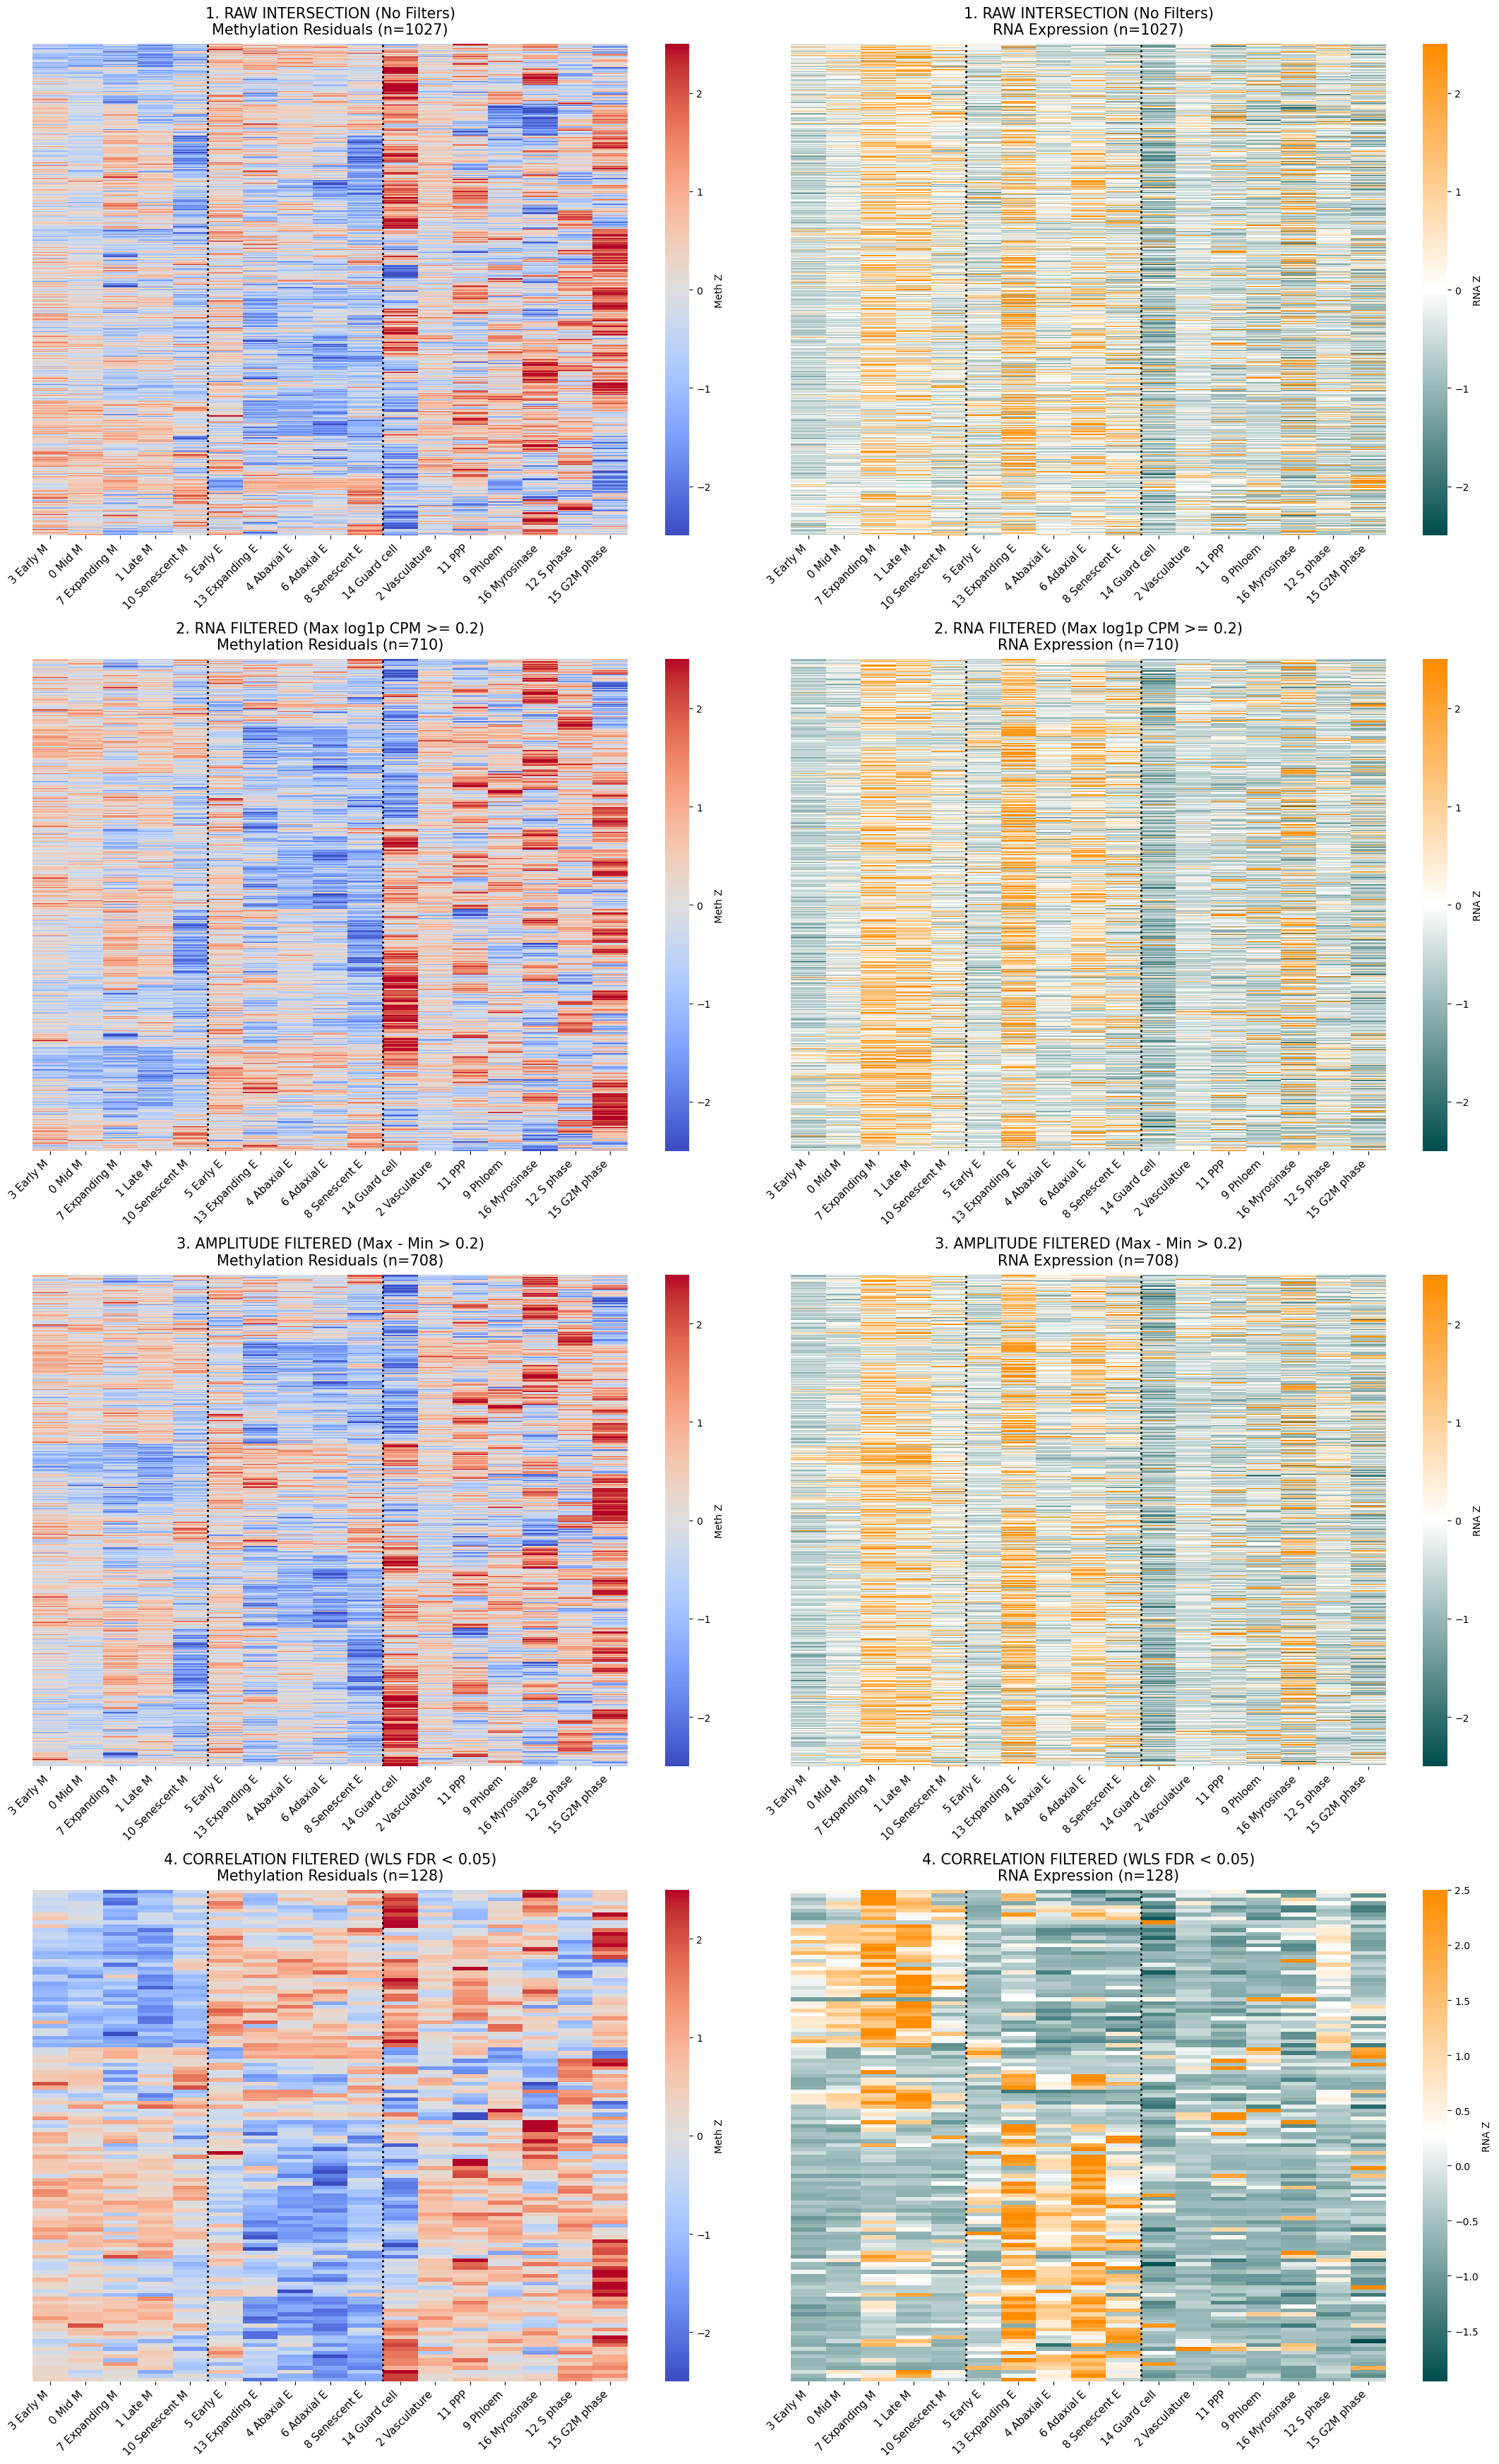

In [13]:
# ==========================================
# MASTER 4-TIER UNCOLLAPSED HEATMAP SCRIPT
# ==========================================
from matplotlib.colors import LinearSegmentedColormap
import os
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

teal_rust_cmap = LinearSegmentedColormap.from_list("Teal_Rust", ["#FF8C00", "white", "#004d4d"])
rna_cmap = LinearSegmentedColormap.from_list("Grey_Green", ["white", "forestgreen"])

# Re-assign variables for clean reading
rna_df = uncollapsed_rna_matrix
meth_df = uncollapsed_adj_meth_matrix
weights_df = uncollapsed_cluster_m

# SCOPE 1: No Filter
scope_1_raw = rna_df.index.intersection(meth_df.index).intersection(hazel_genes)
print(f"Scope 1 (Raw Intersection): {len(scope_1_raw)} genes")

# SCOPE 2: RNA CPM >= 0.2 Filter
rna_mask = rna_df.loc[scope_1_raw].max(axis=1) >= 0.2
scope_2_rna = scope_1_raw[rna_mask]
print(f"Scope 2 (RNA >= 0.2): {len(scope_2_rna)} genes")

# SCOPE 3: Amplitude Filter (Max - Min > 0.2)
rna_max = rna_df.loc[scope_1_raw].max(axis=1)
rna_min = rna_df.loc[scope_1_raw].min(axis=1)
amplitude_mask = (rna_max - rna_min) > 0.2
scope_exploratory_amp = scope_1_raw[amplitude_mask]
print(f"Scope 3 (Max - Min > 0.2): {len(scope_exploratory_amp)} genes")

# SCOPE 4: Correlation Score Filter (WLS FDR < 0.05)
valid_genes, p_vals = [], []
for gene in scope_2_rna:
    r_vals = rna_df.loc[gene, cluster_order].values
    m_vals = meth_df.loc[gene, cluster_order].values
    w_vals = weights_df.loc[gene, cluster_order].values
    
    if np.std(r_vals) == 0 or np.std(m_vals) == 0:
        continue
        
    try:
        mod = sm.WLS(zscore(r_vals), sm.add_constant(zscore(m_vals)), weights=w_vals).fit()
        valid_genes.append(gene)
        p_vals.append(mod.pvalues[1])
    except:
        continue

stats_df = pd.DataFrame({'pval': p_vals}, index=valid_genes)
if len(stats_df) > 0:
    stats_df['fdr'] = multipletests(stats_df['pval'], method='fdr_bh')[1]
    scope_3_sig = stats_df[stats_df['fdr'] < 0.05].index
else:
    scope_3_sig = pd.Index([])
print(f"Scope 4 (FDR < 0.05): {len(scope_3_sig)} genes")

# Plotting Function
def get_clustered_data(genes):
    z_meth = meth_df.loc[genes, cluster_order].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    z_rna = rna_df.loc[genes, cluster_order].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth.values), method='ward')
        order = hc.leaves_list(linkage)
        return z_meth.iloc[order], z_rna.iloc[order]
    return z_meth, z_rna

# Build the Plot
fig, axes = plt.subplots(4, 2, figsize=(22, 35)) 
scopes = [
    (scope_1_raw, "1. RAW INTERSECTION (No Filters)"),
    (scope_2_rna, "2. RNA FILTERED (Max log1p CPM >= 0.2)"),
    (scope_exploratory_amp, "3. AMPLITUDE FILTERED (Max - Min > 0.2)"),
    (scope_3_sig, "4. CORRELATION FILTERED (WLS FDR < 0.05)")
]

for i, (genes, title) in enumerate(scopes):
    if len(genes) == 0:
        continue
        
    m_plot, r_plot = get_clustered_data(genes)
    
    # Meth Heatmap
    sns.heatmap(m_plot, cmap="coolwarm", center=0, ax=axes[i, 0], cbar_kws={'label': 'Meth Z'}, yticklabels=False)
    axes[i, 0].set_title(f"{title}\nMethylation Residuals (n={len(genes)})", fontsize=15, pad=10)
    
    # RNA Heatmap
    sns.heatmap(r_plot, cmap=teal_rust_cmap, ax=axes[i, 1], cbar_kws={'label': 'RNA Z'}, yticklabels=False)
    axes[i, 1].set_title(f"{title}\nRNA Expression (n={len(genes)})", fontsize=15, pad=10)

# Global Formatting
for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
    
    # Dividers precisely placed for 5 Meso subtypes and 5 Epi subtypes
    ax.axvline(5, color='black', lw=2, linestyle=':')  
    ax.axvline(10, color='black', lw=2, linestyle=':') 

plt.tight_layout()

# Save the High-Res Figure
save_dir = './figures/heatmaps/'
file_name = '4_tier_uncollapsed_comparison.png'
os.makedirs(save_dir, exist_ok=True)
full_path = os.path.join(save_dir, file_name)
plt.savefig(full_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Stitched heatmap successfully saved to: {full_path}")

plt.show()

In [3]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


# filtered_meth_df

In [5]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# # Filter for genes that actually have meaningful methylation in at least one cluster
# highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
# filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13764, 17)


In [6]:
import statsmodels.api as sm
from scipy.stats import zscore

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529
AT2G04825 -1.384154  0.003283  0.206739
AT1G52240 -1.302113  0.001152  0.122335
AT3G21670 -1.298125  0.000027  0.011065
AT3G55735 -1.297038  0.000452  0.069419
AT3G26290 -1.294671  0.000006  0.004282
AT5G49740 -1.251251  0.000018  0.008440
AT2G05615 -1.246359  0.018173  0.376778
AT4G04330 -1.238686  0.014208  0.341467
AT3G29033 -1.235975  0.041621  0.471824
AT4G04265 -1.222466  0.010509  0.302969
AT5G23060 -1.201050  0.020242  0.387271
AT2G07764 -1.197692  0.272472  0.744871
AT5G57760 -1.196886  0.000578  0.081813
AT1G58290 -1.196723  0.000166  0.039083
AT4G38870 -1.191051  0.002114  0.173913


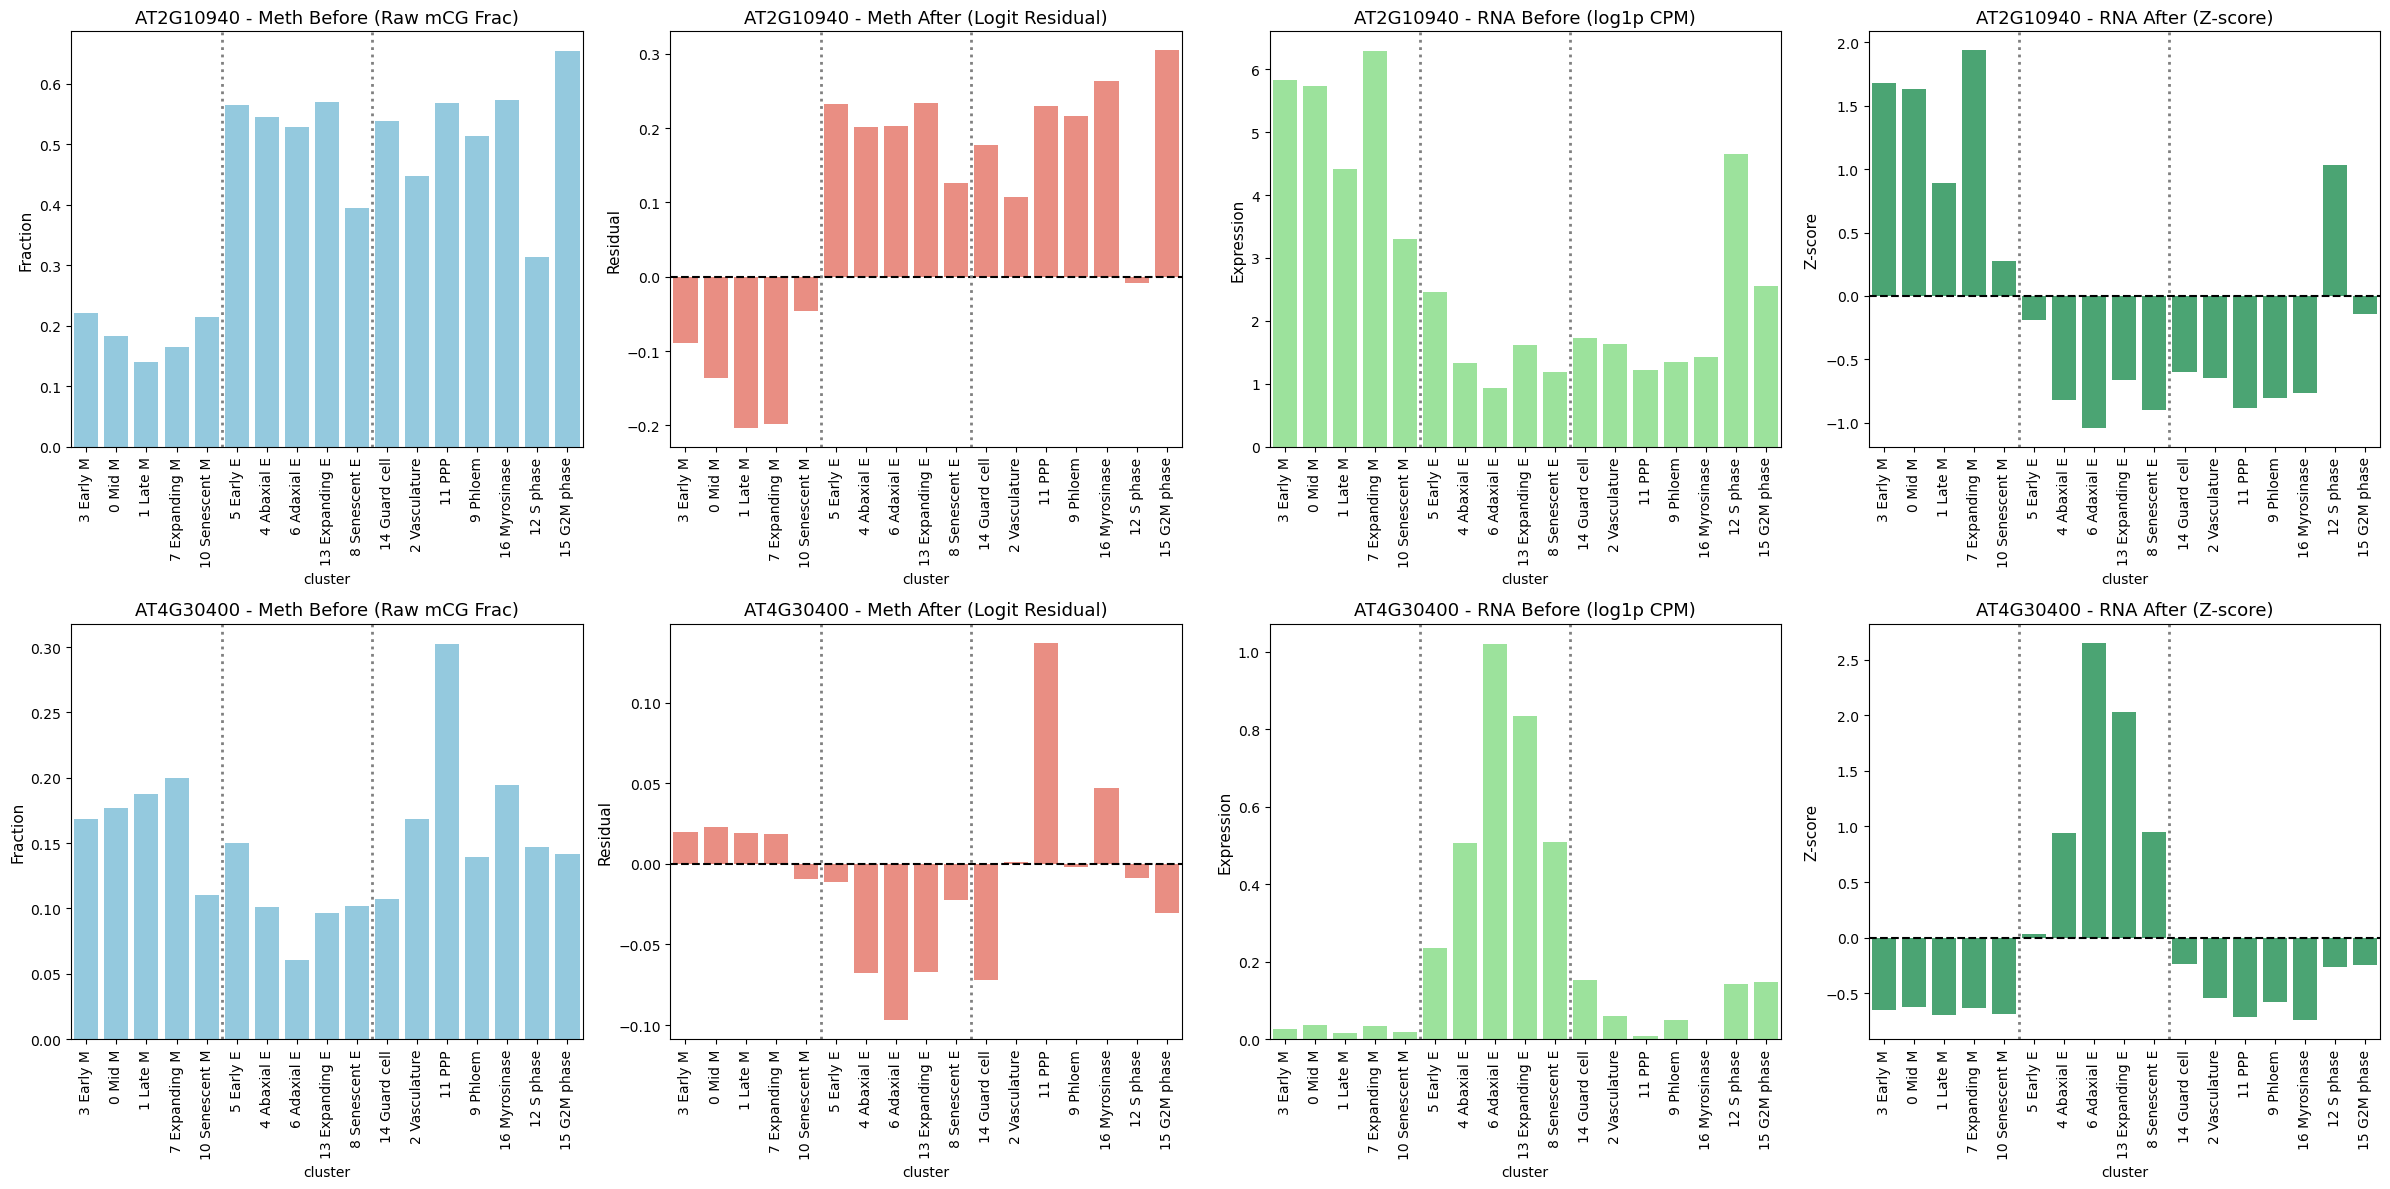

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore

genes_to_check = ['AT2G10940', 'AT4G30400']

# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 1: '1 Late M', 7: '7 Expanding M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '1 Late M', '7 Expanding M', '10 Senescent M',
    '5 Early E', '4 Abaxial E', '6 Adaxial E', '13 Expanding E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

fig, axes = plt.subplots(len(genes_to_check), 4, figsize=(24, 6 * len(genes_to_check)))

if len(genes_to_check) == 1:
    axes = [axes]

for i, gene in enumerate(genes_to_check):
    # --- Data Extraction & Transformation ---
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene].rename(index=cluster_mapping)
        meth_adj = adj_meth_matrix.loc[gene].rename(index=cluster_mapping)
        valid_meth_order = [c for c in cluster_order if c in meth_raw.index]
        meth_raw = meth_raw.reindex(valid_meth_order)
        meth_adj = meth_adj.reindex(valid_meth_order)
        
    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene].rename(index=cluster_mapping)
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        valid_rna_order = [c for c in cluster_order if c in rna_raw.index]
        rna_raw = rna_raw.reindex(valid_rna_order)
        rna_z = rna_z.reindex(valid_rna_order)

    # --- Panel 1: Methylation Before ---
    ax1 = axes[i, 0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG Frac)", fontsize=13)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax1.tick_params(axis='x', rotation=90)
    
    # --- Panel 2: Methylation After ---
    ax2 = axes[i, 1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Logit Residual)", fontsize=13)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax2.tick_params(axis='x', rotation=90)

    # --- Panel 3: RNA Before ---
    ax3 = axes[i, 2]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax3, color='lightgreen')
        ax3.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=13)
        ax3.set_ylabel("Expression", fontsize=11)
    else:
        ax3.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax3.tick_params(axis='x', rotation=90)

    # --- Panel 4: RNA After ---
    ax4 = axes[i, 3]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax4, color='mediumseagreen')
        ax4.set_title(f"{gene} - RNA After (Z-score)", fontsize=13)
        ax4.set_ylabel("Z-score", fontsize=11)
        ax4.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax4.tick_params(axis='x', rotation=90)

    # Add vertical dividers to separate cell types visually
    for ax in [ax1, ax2, ax3, ax4]:
        ax.axvline(4.5, color='gray', linestyle=':', lw=2) # Divider after Mesophyll
        ax.axvline(9.5, color='gray', linestyle=':', lw=2) # Divider after Epidermis

plt.tight_layout()
plt.show()